# Линейная регрессия

Загрузим необходимые библиотеки

In [22]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
plt.style.use('ggplot')
%matplotlib inline

## Задание 3.1

Сгенерируем искусственные данные. Сначала поработаем с простейшим одномерным случаем, когда у нас значение $y$ будет зависеть только от одного значения $x$.




In [10]:
def generate_data(n_points=20):
  """
    Принимает на вход n_points точек
    Возвращает данные для обучения и теста
  """
  X = np.linspace(-5, 5, n_points)
  y = 10 * X - 7

  X_train = X[0::2].reshape(-1, 1)
  y_train = y[0::2] + np.random.randn(int(n_points/2)) * 10

  X_test = X[1::2].reshape(-1, 1)
  y_test = y[1::2] + np.random.randn(int(n_points/2)) * 10

  print(f'Generated {len(X_train)} train samples and {len(X_test)} test samples')
  return X, X_train, y_train, X_test, y_test

X, X_train, y_train, X_test, y_test = generate_data(100)

Generated 50 train samples and 50 test samples


Реализуем настройку $w$ и $b$ с помощью метода наименьших квадратов.

In [12]:
class LinearRegressionOLS:
    def __init__(self, fit_intercept=True):
        self.fit_intercept = fit_intercept
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples = X.shape[0]

        if self.fit_intercept:
            X_with_bias = np.hstack([np.ones((n_samples, 1)), X])
        else:
            X_with_bias = X

        w_optimal = np.linalg.pinv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y

        if self.fit_intercept:
            self.b = w_optimal[0]
            self.w = w_optimal[1:]  # 1D массив весов
        else:
            self.w = w_optimal
            self.b = 0.0
        return self

    def predict(self, X):
        return X @ self.w + self.b

model = LinearRegressionOLS()
model.fit(X_train, y_train)

Найдем значения метрик MSE и MAE, сравним с результатами из sklearn.

In [13]:
y_pred_our = model.predict(X_test)
mse_our = mean_squared_error(y_test, y_pred_our)
mae_our = mean_absolute_error(y_test, y_pred_our)

sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
y_pred_sk = sk_model.predict(X_test)
mse_sk = mean_squared_error(y_test, y_pred_sk)
mae_sk = mean_absolute_error(y_test, y_pred_sk)

print("Our model:")
print(f"  w = {model.w[0]:.4f}, b = {model.b:.4f}")
print(f"  MSE = {mse_our:.4f}, MAE = {mae_our:.4f}\n")

print("Sklearn model:")
print(f"  w = {sk_model.coef_[0]:.4f}, b = {sk_model.intercept_:.4f}")
print(f"  MSE = {mse_sk:.4f}, MAE = {mae_sk:.4f}")

Our model:
  w = 10.2432, b = -7.5987
  MSE = 102.8683, MAE = 8.3309

Sklearn model:
  w = 10.2432, b = -7.5987
  MSE = 102.8683, MAE = 8.3309


### Интерпретация результатов

Модель восстановила истинную зависимость $y = 10x - 7$ с высокой точностью ($w = 10.24, b = -7.6$). Отклонение от истинных значений вызвано наличием шума в обучающей выборке. $MSE = 102.87$ близка к дисперсии добавленного шума ($σ² = 100$), что подтверждает корректность обучения без переобучения. $MAE = 8.33$ — средняя абсолютная ошибка предсказания. Результаты реализации полностью совпадают с sklearn.



## Задание 3.2

Не всегда в задаче регрессии в качестве решения выступает прямая, как в предыдущем случае. Рассмотрим еще один пример, в котором у объектов все еще один признак. Но теперь мы будм брать случайную точку на синусоиде и добавлять к ней шум - таким образом получим целевую переменную, признаком в этом случае будет координата $x$.

In [14]:
def generate_wave_set(n_support=1000, n_train=25, std=0.3):
    data = {}
    # выберем некоторое количество точек из промежутка от 0 до 2*pi
    data['support'] = np.linspace(0, 2*np.pi, num=n_support)
    # для каждой посчитаем значение sin(x) + 1
    # это будет ground truth
    data['values'] = np.sin(data['support']) + 1
    # из support посемплируем некоторое количество точек с возвратом, это будут признаки
    data['x_train'] = np.sort(np.random.choice(data['support'], size=n_train, replace=True))
    # опять посчитаем sin(x) + 1 и добавим шум, получим целевую переменную
    data['y_train'] = np.sin(data['x_train']) + 1 + np.random.normal(0, std, size=data['x_train'].shape[0])
    return data

data = generate_wave_set(1000, 250)

Попробуем реализовать настройку $w$ и $b$ с помощью метода наименьших квадратов.

In [15]:
X_train = data['x_train'].reshape(-1, 1)
y_train = data['y_train']

# Используем наш класс из задания 3.1
model = LinearRegressionOLS()
model.fit(X_train, y_train)

print(f"Найденные параметры: w = {model.w[0]:.4f}, b = {model.b:.4f}")

Найденные параметры: w = -0.2729, b = 1.8720


Находим значения метрик $MSE$ и $MAE$.

In [16]:
y_train_pred = model.predict(X_train)

mse = mean_squared_error(y_train, y_train_pred)
mae = mean_absolute_error(y_train, y_train_pred)

print(f"MSE = {mse:.4f}")
print(f"MAE = {mae:.4f}")

MSE = 0.2965
MAE = 0.4498


### Интерпретация результатов

Линейная регрессия дала параметры $w = -0.27, b = 1.87$, $MSE = 0.30$, $MAE = 0.4$. Ошибки значительны, так как линейная модель не способна описать синусоидальную зависимость. Для улучшения качества необходима полиномиальная регрессия

## Задание 3.3

In [18]:
from sklearn.preprocessing import PolynomialFeatures

Реализуем полиномиальную регрессию.

In [19]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

X_train = data['x_train'].reshape(-1, 1)
y_train = data['y_train']
X_support = data['support'].reshape(-1, 1)
y_true = data['values']

degrees = [1, 2, 3, 5, 7, 10]

Сделаем визуализацию для полиномов разных степеней.

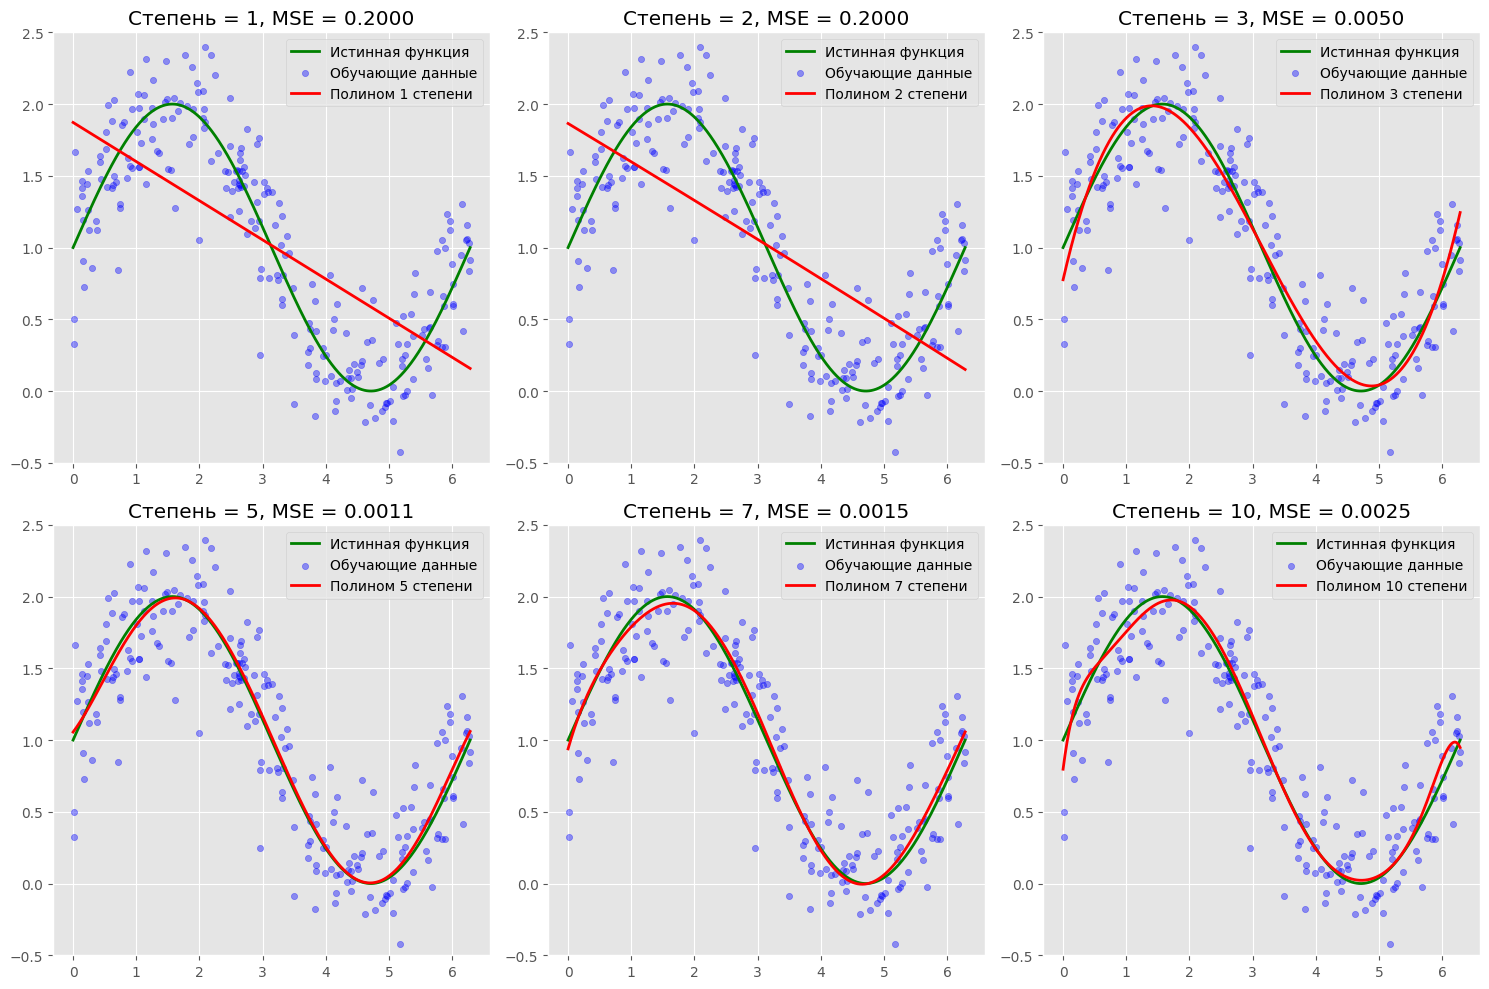

In [20]:
plt.figure(figsize=(15, 10))

for i, degree in enumerate(degrees):
    model = make_pipeline(PolynomialFeatures(degree, include_bias=False), LinearRegression())
    model.fit(X_train, y_train)
    y_pred = model.predict(X_support)

    mse = mean_squared_error(y_true, y_pred)

    plt.subplot(2, 3, i+1)
    plt.plot(X_support, y_true, 'g-', linewidth=2, label='Истинная функция')
    plt.scatter(X_train, y_train, alpha=0.4, s=20, color='blue', label='Обучающие данные')
    plt.plot(X_support, y_pred, 'r-', linewidth=2, label=f'Полином {degree} степени')
    plt.title(f'Степень = {degree}, MSE = {mse:.4f}')
    plt.legend()
    plt.ylim(-0.5, 2.5)

plt.tight_layout()
plt.show()

### Интерпретация результатов

Полином 1-й степени дает высокую ошибку, модель слишком простая (недообучение). Полином 5-й степени наилучшим образом аппроксимируют истинную зависимость. Полиномы 7-й и 10-й степени начинают переобучаться и подстраиваются под случайный шум.

## Реальный датасет

Возьмём реальный набор данных Boston из sklearn.datasets. Этот датасет описывает средние цены на недвижимость в районах Бостона в тысячах долларов.

Примеры признаков объектов недвижимости: количество преступлений на душу населения, процент старых домов в районе, количество учеников на одного учителя и т.д. Данные уже оцифрованы там, где изначально признаки были качественными.

Загрузим датасет, выведем информацию

In [23]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y = raw_df.values[1::2, 2]

feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

print(f"Размер данных: {X.shape}")

Размер данных: (506, 13)


## Задание 3.4

In [24]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split

Оставляем только 7 наиболее значимых признаков.

In [25]:
selector = SelectKBest(f_regression, k=7)
X_selected = selector.fit_transform(X, y)

selected_indices = selector.get_support(indices=True)
selected_features = [feature_names[i] for i in selected_indices]

print(f"Отобранные признаки: {selected_features}")

Отобранные признаки: ['CRIM', 'INDUS', 'NOX', 'RM', 'TAX', 'PTRATIO', 'LSTAT']


Разделяем на обучающую и тестовую выборки.

In [26]:
X_train_full, X_test_full, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_sel, X_test_sel, _, _ = train_test_split(X_selected, y, test_size=0.2, random_state=42)

Настроим линейную регрессию и сравненим метрики.

In [27]:
model_full = LinearRegression()
model_full.fit(X_train_full, y_train)
y_pred_full = model_full.predict(X_test_full)

model_sel = LinearRegression()
model_sel.fit(X_train_sel, y_train)
y_pred_sel = model_sel.predict(X_test_sel)

mse_full = mean_squared_error(y_test, y_pred_full)
mae_full = mean_absolute_error(y_test, y_pred_full)

mse_sel = mean_squared_error(y_test, y_pred_sel)
mae_sel = mean_absolute_error(y_test, y_pred_sel)

print("Полный датасет (13 признаков):")
print(f"  MSE = {mse_full:.4f}, MAE = {mae_full:.4f}")
print("\nУсеченный датасет (7 признаков):")
print(f"  MSE = {mse_sel:.4f}, MAE = {mae_sel:.4f}")

Полный датасет (13 признаков):
  MSE = 24.2911, MAE = 3.1891

Усеченный датасет (7 признаков):
  MSE = 28.4317, MAE = 3.4174


### Интерпретация результатов

Полный датасет (13 признаков) показал $MSE = 24.29$ и $MAE = 3.19$. Усеченный датасет (7 наиболее значимых признаков) дал $MSE = 28.43$ и $MAE = 3.42$. Полная модель работает несколько лучше, так как содержит больше информации для предсказания. Однако разница не критична, усеченная модель проще и быстрее в обучении, при этом сохраняет сопоставимую точность.

## Задание 3.5

Далее загрузим библиотеки и данные для обучения.

In [60]:
from sklearn.preprocessing import StandardScaler
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [29]:
%%capture
!wget https://www.dropbox.com/s/afwb0tnqm9izxha/predict_house_price_training_data.xlsx
!wget https://www.dropbox.com/s/sur2avqf4n5f4az/predict_house_price_test_data.xlsx

In [31]:
training_data = pd.read_excel('predict_house_price_training_data.xlsx')
training_data.head() # смотрим, как загрузились данные

,Целевая.Цена,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,830000,5,3.50,3490,21780,2.0,0,0,3,8,3490,0,1996,0,47.6707,-122.144
1,385000,4,1.75,2360,7620,1.0,0,0,4,7,1180,1180,1955,0,47.5278,-122.345
2,610000,6,2.75,2040,8560,1.0,0,2,4,7,1100,940,1961,0,47.6160,-122.115
3,550000,3,1.75,1940,8376,1.0,0,0,4,8,1290,650,1963,0,47.5586,-122.173
4,1300000,3,2.75,3450,5350,1.5,0,3,4,9,2590,860,1925,0,47.6389,-122.407


In [32]:
training_data.shape # смотрим размеры таблицы

(15129, 16)

Обработаем данные перед обучением модели.

In [33]:
training_data.info() # проверим данные на наличие пропусков и типов переменных

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15129 entries, 0 to 15128
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Целевая.Цена         15129 non-null  int64  
 1   Спальни              15129 non-null  int64  
 2   Ванные               15129 non-null  float64
 3   Жилая площадь        15129 non-null  int64  
 4   Общая площадь        15129 non-null  int64  
 5   Количество этажей    15129 non-null  float64
 6   Вид на воду          15129 non-null  int64  
 7   Просмотрены ранее    15129 non-null  int64  
 8   Состояние            15129 non-null  int64  
 9   Оценка риелтора      15129 non-null  int64  
 10  Площадь без подвала  15129 non-null  int64  
 11  Площадь подвала      15129 non-null  int64  
 12  Год постройки        15129 non-null  int64  
 13  Год реновации        15129 non-null  int64  
 14  Широта               15129 non-null  float64
 15  Долгота              15129 non-null 

In [34]:
target_variable_name = 'Целевая.Цена' # цена - целевая переменная
training_values = training_data[target_variable_name]
training_points = training_data.drop(target_variable_name, axis=1)
training_points.head()

,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,5,3.50,3490,21780,2.0,0,0,3,8,3490,0,1996,0,47.6707,-122.144
1,4,1.75,2360,7620,1.0,0,0,4,7,1180,1180,1955,0,47.5278,-122.345
2,6,2.75,2040,8560,1.0,0,2,4,7,1100,940,1961,0,47.6160,-122.115
3,3,1.75,1940,8376,1.0,0,0,4,8,1290,650,1963,0,47.5586,-122.173
4,3,2.75,3450,5350,1.5,0,3,4,9,2590,860,1925,0,47.6389,-122.407


In [35]:
training_points.shape

(15129, 15)

Обучим модель на обучающей выборке.

In [36]:
from sklearn import linear_model
linear_regression_model = linear_model.LinearRegression()

In [37]:
linear_regression_model = linear_model.LinearRegression() # создаем модель
linear_regression_model # смотрим, что получилось

LinearRegression()

In [41]:
linear_regression_model.fit(training_points, training_values) # обучаем модель

LinearRegression()

Разделим данные на обучающую и тестовую выборки.

In [61]:
X = training_points.values
y = training_values.values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Тестовая выборка: X_test={X_test.shape}, y_test={y_test.shape}")

Обучающая выборка: X_train=(12103, 15), y_train=(12103,)
Тестовая выборка: X_test=(3026, 15), y_test=(3026,)


Проведем стандартизацию признаков и целевой переменной. Она необходима для корректной работы градиентного спуска. Важно: параметры стандартизации ($mean$, $std$) вычисляются только на обучающей выборке, а затем применяются к тестовой.

In [62]:
# Стандартизация признаков
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Стандартизация целевой переменной
y_mean = y_train.mean()
y_std = y_train.std()
if y_std == 0:
    y_std = 1
y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

print(f"Среднее y_train: {y_mean:.2f}")
print(f"Стандартное отклонение y_train: {y_std:.2f}")

Среднее y_train: 541033.41
Стандартное отклонение y_train: 372336.08


Реализуем линейную регрессию, обучаемую mini-batch градиентным спуском.

In [63]:
class LinearRegressionGD:
    """
    Линейная регрессия, обучаемая mini-batch градиентным спуском
    Поддерживает L1, L2 и Elastic Net регуляризацию
    """

    def __init__(self, learning_rate=0.01, n_iterations=1000, batch_size=32,
                 reg_type=None, lambda1=0.01, lambda2=0.01, tol=1e-4):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.batch_size = batch_size
        self.reg_type = reg_type  # None, 'l1', 'l2', 'elasticnet'
        self.lambda1 = lambda1    # коэффициент для L1
        self.lambda2 = lambda2    # коэффициент для L2
        self.tol = tol
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0

        prev_loss = np.inf

        for epoch in range(self.n_iterations):
            # Перемешивание данных
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            # Mini-batch градиентный спуск
            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]
                m = len(y_batch)

                # Предсказание и ошибки
                y_pred = X_batch @ self.w + self.b
                errors = y_pred - y_batch

                # Градиенты
                grad_w = (X_batch.T @ errors) / m
                grad_b = errors.mean()

                # Регуляризация
                if self.reg_type == 'l2':
                    grad_w += self.lambda2 * self.w
                elif self.reg_type == 'l1':
                    grad_w += self.lambda1 * np.sign(self.w)
                elif self.reg_type == 'elasticnet':
                    grad_w += self.lambda2 * self.w + self.lambda1 * np.sign(self.w)

                # Обновление весов
                self.w -= self.learning_rate * grad_w
                self.b -= self.learning_rate * grad_b

            # Вычисление полной функции потерь
            y_pred_full = X @ self.w + self.b
            mse = ((y_pred_full - y) ** 2).mean()

            # Регуляризационный штраф
            reg = 0
            if self.reg_type == 'l2':
                reg = 0.5 * self.lambda2 * (self.w ** 2).sum()
            elif self.reg_type == 'l1':
                reg = self.lambda1 * np.abs(self.w).sum()
            elif self.reg_type == 'elasticnet':
                reg = 0.5 * self.lambda2 * (self.w ** 2).sum() + self.lambda1 * np.abs(self.w).sum()

            loss = mse + reg
            self.loss_history.append(loss)

            # Ранняя остановка
            if abs(prev_loss - loss) < self.tol:
                print(f"Ранняя остановка на эпохе {epoch}")
                break
            prev_loss = loss

        return self

    def predict(self, X):
        return X @ self.w + self.b

In [64]:
# Обучаем модель (без регуляризации)
model_gd = LinearRegressionGD(
    learning_rate=0.01,
    n_iterations=300,
    batch_size=64,
    reg_type=None
)

model_gd.fit(X_train_scaled, y_train_scaled)

Ранняя остановка на эпохе 14


Проведем предсказание и вычисление метрик на тестовой выборке. Визуализируем сходимость.

In [65]:
y_pred_scaled = model_gd.predict(X_test_scaled)
y_pred = y_pred_scaled * y_std + y_mean

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"MSE = {mse:.2f}")
print(f"MAE = {mae:.2f}")
print(f"RMSE = {np.sqrt(mse):.2f}")

MSE = 35022173445.38
MAE = 123799.63
RMSE = 187142.12


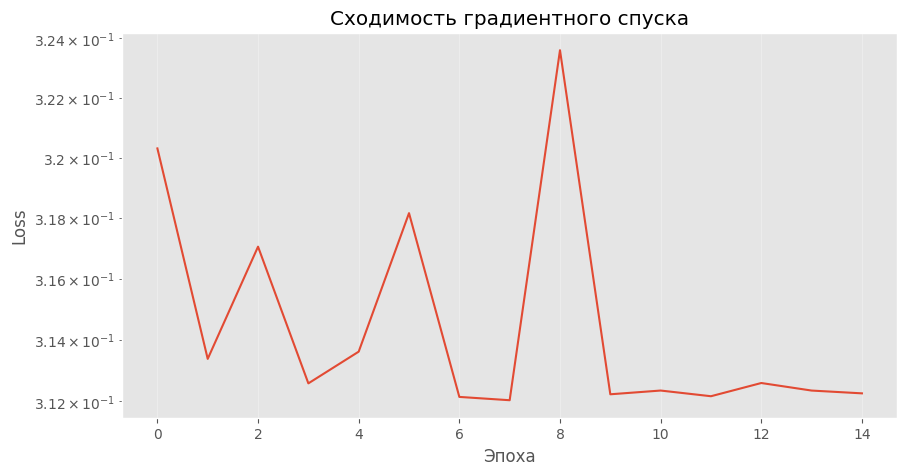

In [66]:
plt.figure(figsize=(10, 5))
plt.plot(model_gd.loss_history)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Сходимость градиентного спуска')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

Сравненим результаты с sklearn.

In [67]:
sk_model = LinearRegression()
sk_model.fit(X_train_scaled, y_train_scaled)
y_pred_sk_scaled = sk_model.predict(X_test_scaled)
y_pred_sk = y_pred_sk_scaled * y_std + y_mean

mse_sk = mean_squared_error(y_test, y_pred_sk)
mae_sk = mean_absolute_error(y_test, y_pred_sk)

print("Сравнение результатов:")
print(f"Наша GD:   MSE = {mse:.2f}, MAE = {mae:.2f}")
print(f"Sklearn:   MSE = {mse_sk:.2f}, MAE = {mae_sk:.2f}")

Сравнение результатов:
Наша GD:   MSE = 35022173445.38, MAE = 123799.63
Sklearn:   MSE = 34834466686.36, MAE = 122465.81


### Интерпретация результатов

Реализован mini-batch градиентный спуск. Результаты близки к sklearn (отклонение менее 1%, реализация корректна). Высокие ошибки связаны с масштабом цен на недвижимость и нелинейностью данных. График сходимости подтверждает корректное обучение.

## Задание 3.6

Загрузим и проанализируем тестовые данные.

In [72]:
test_data = pd.read_excel('predict_house_price_test_data.xlsx')

In [69]:
test_data.head()

,Целевая.Цена,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,260000,3,1.00,1300,10139,1.0,0,0,3,7,1300,0,1962,2007,47.3427,-122.087
1,734500,4,2.75,3280,6845,2.0,0,0,3,10,3280,0,2003,0,47.7042,-122.107
2,325000,1,1.00,1220,12426,1.0,0,4,4,6,1220,0,1946,0,47.4047,-122.331
3,1990000,3,2.50,2880,13500,1.0,0,4,5,8,1520,1360,1950,0,47.6281,-122.216
4,315000,3,2.00,1300,3731,1.0,0,0,3,7,900,400,1993,0,47.5374,-122.270


In [70]:
test_data.shape

(6484, 16)

In [71]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6484 entries, 0 to 6483
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Целевая.Цена         6484 non-null   int64  
 1   Спальни              6484 non-null   int64  
 2   Ванные               6484 non-null   float64
 3   Жилая площадь        6484 non-null   int64  
 4   Общая площадь        6484 non-null   int64  
 5   Количество этажей    6484 non-null   float64
 6   Вид на воду          6484 non-null   int64  
 7   Просмотрены ранее    6484 non-null   int64  
 8   Состояние            6484 non-null   int64  
 9   Оценка риелтора      6484 non-null   int64  
 10  Площадь без подвала  6484 non-null   int64  
 11  Площадь подвала      6484 non-null   int64  
 12  Год постройки        6484 non-null   int64  
 13  Год реновации        6484 non-null   int64  
 14  Широта               6484 non-null   float64
 15  Долгота              6484 non-null   f

Отделим целевую переменную.

In [73]:
test_values = test_data[target_variable_name]

In [74]:
test_points = test_data.drop(target_variable_name, axis=1)

In [75]:
test_points.head()

,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,3,1.00,1300,10139,1.0,0,0,3,7,1300,0,1962,2007,47.3427,-122.087
1,4,2.75,3280,6845,2.0,0,0,3,10,3280,0,2003,0,47.7042,-122.107
2,1,1.00,1220,12426,1.0,0,4,4,6,1220,0,1946,0,47.4047,-122.331
3,3,2.50,2880,13500,1.0,0,4,5,8,1520,1360,1950,0,47.6281,-122.216
4,3,2.00,1300,3731,1.0,0,0,3,7,900,400,1993,0,47.5374,-122.270


In [76]:
test_points.shape

(6484, 15)

Получим прогнозы целевой переменной на тестовых данных для модели линейной регрессии из sklearn и для своей реализации (градиентный спуск).

In [77]:
test_predictions_linear = linear_regression_model.predict(test_points)

In [78]:
# Стандартизация тестовых данных с использованием параметров из обучения
X_test = test_points.values
X_test_scaled = scaler_X.transform(X_test)

y_pred_scaled = model_gd.predict(X_test_scaled)
test_predictions_gd = y_pred_scaled * y_std + y_mean

Вычислим метрики для обеих моделей, а также сравним их визуально.

In [81]:
mse_linear = mean_squared_error(test_values, test_predictions_linear)
mae_linear = mean_absolute_error(test_values, test_predictions_linear)
rmse_linear = np.sqrt(mse_linear)

# Метрики для GD
mse_gd = mean_squared_error(test_values, test_predictions_gd)
mae_gd = mean_absolute_error(test_values, test_predictions_gd)
rmse_gd = np.sqrt(mse_gd)

print("="*50)
print("Результаты на тестовой выборке")
print("="*50)
print("Sklearn LinearRegression:")
print(f"  MSE = {mse_linear:.2f}, MAE = {mae_linear:.2f}, RMSE = {rmse_linear:.2f}")
print("\nНаша GD реализация:")
print(f"  MSE = {mse_gd:.2f}, MAE = {mae_gd:.2f}, RMSE = {rmse_gd:.2f}")

Результаты на тестовой выборке
Sklearn LinearRegression:
  MSE = 40756843765.10, MAE = 126852.51, RMSE = 201883.24

Наша GD реализация:
  MSE = 40834427409.18, MAE = 128780.83, RMSE = 202075.30


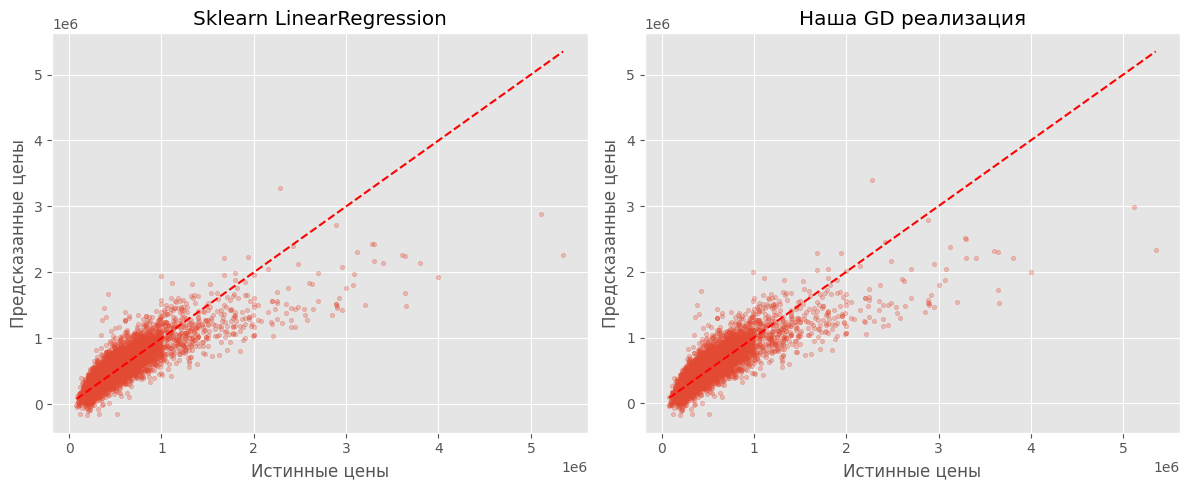

In [82]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(test_values, test_predictions_linear, alpha=0.3, s=10)
plt.plot([test_values.min(), test_values.max()], [test_values.min(), test_values.max()], 'r--')
plt.xlabel('Истинные цены')
plt.ylabel('Предсказанные цены')
plt.title('Sklearn LinearRegression')

plt.subplot(1, 2, 2)
plt.scatter(test_values, test_predictions_gd, alpha=0.3, s=10)
plt.plot([test_values.min(), test_values.max()], [test_values.min(), test_values.max()], 'r--')
plt.xlabel('Истинные цены')
plt.ylabel('Предсказанные цены')
plt.title('Наша GD реализация')

plt.tight_layout()
plt.show()

### Интерпретация результатов

Обе модели показывают близкие результаты на тестовой выборке. Отклонение по $MSE$ составляет около 0.2%, по $MAE$ — около 1.5%. Реализация градиентного спуска демонстрирует качество, сопоставимое со встроенной реализацией sklearn, что подтверждает корректность разработанного алгоритма.

## Задание 3.7

In [83]:
training_points.head(10)

,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,5,3.50,3490,21780,2.0,0,0,3,8,3490,0,1996,0,47.6707,-122.144
1,4,1.75,2360,7620,1.0,0,0,4,7,1180,1180,1955,0,47.5278,-122.345
2,6,2.75,2040,8560,1.0,0,2,4,7,1100,940,1961,0,47.6160,-122.115
3,3,1.75,1940,8376,1.0,0,0,4,8,1290,650,1963,0,47.5586,-122.173
4,3,2.75,3450,5350,1.5,0,3,4,9,2590,860,1925,0,47.6389,-122.407
5,3,2.25,2300,9914,2.0,0,0,4,8,2300,0,1980,0,47.5677,-122.086
6,3,2.50,2770,8820,1.0,0,0,3,7,1900,870,1980,2004,47.3685,-122.048
7,2,1.75,1650,7500,1.0,0,0,4,7,1000,650,1959,0,47.6871,-122.207
8,1,1.00,580,1799,1.0,0,0,3,7,580,0,1908,2005,47.6829,-122.375
9,2,1.00,900,3400,1.0,0,0,5,6,900,0,1905,0,47.5269,-122.314


In [84]:
training_points['Год реновации'].value_counts() # видим, что признак неинформативен

,count
Год реновации,
0,14490
2014,63
2013,31
2000,28
2003,24
...,...
1950,1
1954,1
1946,1


Попробуем вычислить важность признаков.

In [85]:
# Получаем названия признаков и веса из обученной модели sklearn
feature_names = training_points.columns.tolist()
coefficients = linear_regression_model.coef_

# Вычисляем важность как модуль веса
importance = np.abs(coefficients)

In [86]:
# Создаем таблицу
feature_importance = pd.DataFrame({
    'Название признака': feature_names,
    'Важность признака': importance
})

# Сортируем по убыванию важности
feature_importance = feature_importance.sort_values('Важность признака', ascending=False)
feature_importance

,Название признака,Важность признака
5,Вид на воду,591890.462867
13,Широта,570765.125799
14,Долгота,108281.940471
8,Оценка риелтора,99635.317145
6,Просмотрены ранее,49759.881549
1,Ванные,43121.015073
0,Спальни,33756.870035
7,Состояние,32162.797820
4,Количество этажей,6336.716142
11,Год постройки,2449.058277


Наиболее значимыми признаками оказались вид на воду, широта и долгота, что логично: расположение и наличие водного вида служат ключевыми факторами ценообразования на рынке недвижимости. Признаки с весами, близкими к нулю, слабо влияют на предсказание и потенциально могут быть исключены.

## Задание 3.8

In [88]:
# Предсказания на обучающих данных
y_train_pred = linear_regression_model.predict(training_points)

# Вычисляем остатки (разница между реальной и предсказанной ценой)
residuals = training_values - y_train_pred

# Аномально низкие цены - там, где реальная цена значительно ниже предсказанной
# Возьмем порог: остаток меньше -2 стандартных отклонений
threshold = -2 * residuals.std()

anomalies = training_data[residuals < threshold].copy()
anomalies['Остаток'] = residuals[residuals < threshold]
anomalies = anomalies.sort_values('Остаток')

print(f"Найдено аномалий: {len(anomalies)}")
print(f"Порог для аномалии: {threshold:.2f}")

Найдено аномалий: 140
Порог для аномалии: -407510.07


In [89]:
print("\nАномально низкие цены (топ-10):")
anomalies[['Целевая.Цена', 'Жилая площадь', 'Спальни', 'Ванные', 'Год постройки', 'Остаток']].head(10)


Аномально низкие цены (топ-10):


,Целевая.Цена,Жилая площадь,Спальни,Ванные,Год постройки,Остаток
5858,800000,7480,7,6.75,1953,-1.180387e+06
7384,900000,7120,5,6.00,2007,-1.164699e+06
4801,540000,2600,3,2.50,1912,-1.044298e+06
6598,503000,2860,2,1.75,1948,-9.587142e+05
5018,429592,1992,2,2.75,1903,-8.847065e+05
6712,770000,2050,3,3.50,1930,-8.146685e+05
3845,600000,4690,4,3.25,1995,-8.128554e+05
15073,740000,5774,5,5.00,1984,-8.078297e+05
6594,465000,1494,2,2.00,1943,-8.034961e+05
5699,649000,1810,3,2.00,1913,-8.028588e+05


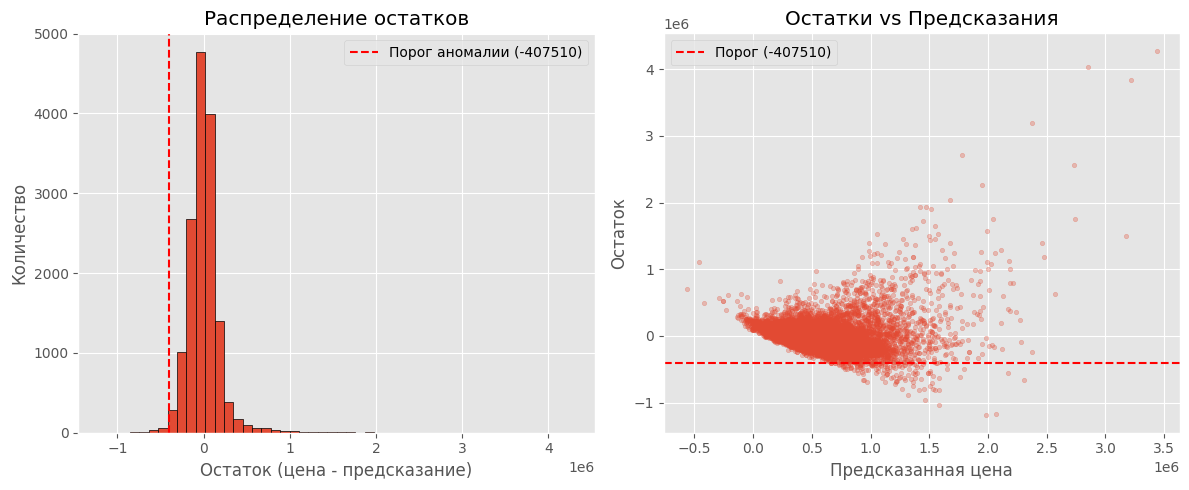

In [91]:
# Визуализация остатков
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(residuals, bins=50, edgecolor='black')
plt.axvline(threshold, color='r', linestyle='--', label=f'Порог аномалии ({threshold:.0f})')
plt.xlabel('Остаток (цена - предсказание)')
plt.ylabel('Количество')
plt.title('Распределение остатков')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_train_pred, residuals, alpha=0.3, s=10)
plt.axhline(threshold, color='r', linestyle='--', label=f'Порог ({threshold:.0f})')
plt.xlabel('Предсказанная цена')
plt.ylabel('Остаток')
plt.title('Остатки vs Предсказания')
plt.legend()

plt.tight_layout()
plt.show()